# 02 — LLM-as-Policy: Single-Agent Zero-Shot Battery Control

**Phase 2** · MSc Thesis

Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

Evaluates frontier LLMs as zero-shot battery controllers in a **single group-centralized agent setup** over 3 buildings (`TRAINING_BUILDINGS=[0,1,2]`).

One API call per step, 3 actions per call. Aligns with the Phase 3 SFT training shape — at Phase 4 deployment the same agent is instantiated twice (α on B0–2, β on B3–5) but **here we stay single-agent**.

**Rollout window:** 300 hourly steps starting at `t=3624`.

**Providers tested:**

| Provider | Model | API quirks |
|----------|-------|------------|
| Anthropic | `claude-haiku-4-5` | Native client; standard `max_tokens`, `temperature=0`. |
| DeepSeek | `deepseek-chat` (V3) | OpenAI-compat; standard `max_tokens`, `temperature=0`. |
| Kimi | `kimi-k2.5` | OpenAI-compat (Moonshot); **requires `temperature=1`**. |
| OpenAI | `gpt-5.4-nano` | Reasoning-family — uses **`max_completion_tokens`**, **`temperature=1`** only. |

**API keys:** loaded from `.env`. Required: `ANTHROPIC_API_KEY`, `DEEPSEEK_API_KEY`, `KIMI_API_KEY`, `OPENAI_API_KEY`.


## § 0 — Config
> **Change experiment parameters here only.** Nothing else needs editing.

In [1]:
import sys
from pathlib import Path

# ── Make src/ importable ──────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from src.env import TRAINING_BUILDINGS

# ── Provider list ─────────────────────────────────────────────────────────
PROVIDERS: list[dict] = [
    {"name": "anthropic", "model": "claude-haiku-4-5", "key_env": "ANTHROPIC_API_KEY", "base_url": None},
    {"name": "deepseek",  "model": "deepseek-chat",    "key_env": "DEEPSEEK_API_KEY",  "base_url": "https://api.deepseek.com/v1"},
    {"name": "kimi",      "model": "kimi-k2.5",         "key_env": "KIMI_API_KEY",      "base_url": "https://api.moonshot.ai/v1", "temperature": 1.0},
    {"name": "openai",    "model": "gpt-5.4-nano",      "key_env": "OPENAI_API_KEY",    "base_url": None},
]

# ── Single-agent buildings (Phase 3 design — see CLAUDE.md) ───────────────
BUILDINGS: list[int] = TRAINING_BUILDINGS   # [0, 1, 2]
N_BLDGS:   int        = len(BUILDINGS)

# ── Timeout ──────────────────────────────────────────────────────────────
LLM_TIMEOUT_S: float = 45.0

# ── Experiment window ─────────────────────────────────────────────────────
WEEK_START: int = 3624
WEEK_LEN:   int = 300

# ── Output ───────────────────────────────────────────────────────────────
ARTIFACTS = Path("artifacts").resolve()
ARTIFACTS.mkdir(exist_ok=True)

# ── Sanity print ─────────────────────────────────────────────────────────
import os
print(f"Project root   : {PROJECT_ROOT}")
print(f"Window         : t{WEEK_START}..{WEEK_START + WEEK_LEN - 1} ({WEEK_LEN} steps)")
print(f"Single agent   : buildings {BUILDINGS}  (N_BLDGS={N_BLDGS})")
print(f"Timeout/call   : {LLM_TIMEOUT_S}s")
print(f"\nProviders ({len(PROVIDERS)}):")
for p in PROVIDERS:
    has_key = bool(os.environ.get(p["key_env"], "").strip())
    flag = "OK" if has_key else "MISSING"
    print(f"  [{flag}] {p['name']:10s} model={p['model']:35s} env={p['key_env']}")


Project root   : /Users/antonisbast/projects/eclipse-thesis
Window         : t3624..3923 (300 steps)
Single agent   : buildings [0, 1, 2]  (N_BLDGS=3)
Timeout/call   : 45.0s

Providers (4):
  [OK] anthropic  model=claude-haiku-4-5                    env=ANTHROPIC_API_KEY
  [OK] deepseek   model=deepseek-chat                       env=DEEPSEEK_API_KEY
  [OK] kimi       model=kimi-k2.5                           env=KIMI_API_KEY
  [OK] openai     model=gpt-5.4-nano                        env=OPENAI_API_KEY


## § 1 — Imports

In [2]:
import concurrent.futures
import json
import logging
import random
import time
import warnings

import citylearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from citylearn.citylearn import CityLearnEnv

# ── Single source of truth: everything domain-specific from src/ ──────────
from src.env       import SEED, make_env, snapshot_state
from src.agent     import (
    PRICE_PEAK_THRESHOLD,
    price_bucket, carbon_bucket, solar_bucket, irradiance_bucket,
    render_state, parse_actions, ACTION_RE,
    make_minimal_prompt, make_policy_llm,
    policy_noop, policy_random, policy_rbc,
)
from src.providers import APIProvider
from src.eval      import evaluate, comparison_table

warnings.filterwarnings("ignore")
np.random.seed(SEED)
random.seed(SEED)

print(f"CityLearn {citylearn.__version__}")
print("src.env, src.agent, src.providers, src.eval all loaded — no inline redefinitions.")


CityLearn 2.6.0b2
src.env, src.agent, src.providers, src.eval all loaded — no inline redefinitions.


## § 1b — Imports note

All domain helpers (state rendering, action parsing, prompt, `APIProvider`, reference policies) come from `src/`. No inline redefinitions in this notebook — `src.agent.make_minimal_prompt` is the canonical CoT prompt; `src.providers.APIProvider` handles remote APIs.


In [3]:
# All helpers imported from src/ in the previous cell.
# The canonical CoT prompt is previewed in § 4.
print('Domain helpers OK — see § 4 for the prompt preview.')

Domain helpers OK — see § 4 for the prompt preview.


## § 2 — Environment

In [4]:
_env = make_env(
    buildings=BUILDINGS,
    start=WEEK_START,
    end=WEEK_START + WEEK_LEN - 1,
    obs_set="llm",
    reward_fn="merlin",
)
_obs, _ = _env.reset()
print(f"buildings      : {len(_obs)}  (single-agent — {BUILDINGS})")
print(f"obs / building : {len(_obs[0])}  (llm obs set — 9 real-time vars)")
print(f"steps / episode: {_env.time_steps}")
print(f"reward fn      : {type(_env.reward_function).__name__}")

_snap = snapshot_state(_env)

print(f"\nsnapshot_state() returns {len(_snap[0])} fields per building (all real-time):")
print(f"  month, day_type, hour, electricity_pricing, carbon_intensity,")
print(f"  solar_generation, non_shiftable_load, electrical_storage_soc,")
print(f"  net_electricity_consumption_last")

print(f"\nBuilding states at t=0:")
for i, d in enumerate(_snap):
    print(
        f"  B{i}: SoC={d['electrical_storage_soc']*100:.1f}%  "
        f"load={d['non_shiftable_load']:.2f}  "
        f"price={d['electricity_pricing']:.3f}  "
        f"solar={d['solar_generation']:.2f}"
    )


buildings      : 3  (single-agent — [0, 1, 2])
obs / building : 9  (llm obs set — 9 real-time vars)
steps / episode: 300
reward fn      : MERLINReward

snapshot_state() returns 9 fields per building (all real-time):
  month, day_type, hour, electricity_pricing, carbon_intensity,
  solar_generation, non_shiftable_load, electrical_storage_soc,
  net_electricity_consumption_last

Building states at t=0:
  B0: SoC=0.0%  load=0.60  price=0.210  solar=0.00
  B1: SoC=0.0%  load=1.68  price=0.210  solar=0.00
  B2: SoC=0.0%  load=0.28  price=0.210  solar=0.00


## § 3 — State Renderer

`snapshot_state()` returns **9 fields** per building — all real-time. The CityLearn
dataset also exposes oracle price/solar forecast columns, but we deliberately
exclude them (see notebook 01 § 2): they are perfect look-ahead reads from the
simulation tape, not a signal a deployed agent could obtain. The LLM is asked
to anticipate future conditions from real-time state alone.

`render_state()` converts the snapshot into a human-readable prompt string, e.g.:

```
Month 12, Wed 08:00  |  price=0.210 (LOW)  |  carbon=0.202 (PEAK)
Buildings:
  B0: SoC= 45.3%  load=1.20 kWh  last_net=+0.85 kWh  solar=LOW
  ...
```

Each agent receives only its **own 3 buildings**. `render_state()` re-labels from B0
regardless of the slice, so both agents see identically structured prompts.

In [5]:
# Single-agent state preview
print("=" * 60)
print(f"Agent state (buildings {BUILDINGS}):")
print("=" * 60)
print(render_state(_snap))


Agent state (buildings [0, 1, 2]):
Month 12, Thu 23:00  |  price=0.210 (LOW)  |  carbon=0.202 (MID)
Buildings:
  B0: SoC=  0.0%  load=0.60 kWh  last_net=+0.00 kWh  solar=NONE
  B1: SoC=  0.0%  load=1.68 kWh  last_net=+0.00 kWh  solar=NONE
  B2: SoC=  0.0%  load=0.28 kWh  last_net=+0.00 kWh  solar=NONE


## § 4 — Prompt Preview

`make_minimal_prompt(3)` is the active prompt — it is printed by the § 1b utilities cell
above and used automatically by every provider cell below.

In [6]:
# Show the prompt the agent will receive
print(make_minimal_prompt(N_BLDGS))


You manage batteries in 3 buildings that share one grid meter. Each step, pick one action per building.

[Actions]
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State]
- 'price' (LOW / MID / PEAK): how expensive grid electricity is now.
- 'carbon' (LOW / MID / HIGH): how dirty grid electricity is now.
- 'solar' (NONE / LOW / MID / HIGH): the building's solar generation now.
- 'load' (kWh): the building's electricity demand now.
- 'SoC' (%): how full the battery is. 0% empty, 100% full.
- 'last_net' (kWh): grid draw last step — your feedback signal.
- Time: month, weekday, hour. No forecasts.

[Physics]
A building's grid draw is its load, minus its solar, plus any charging, minus any discharging. A negative result means the building exports to the grid for almost no reward. The 3 buildings share one meter, so the district's draw is the sum across them. Battery charge stays between 0% and 100%.

[Hint

## § 5 — Provider Setup & Smoke Test

`PROVIDER_OBJS` is initialised in the first cell. Each subsequent cell smoke-tests
**one provider independently** — you can interrupt a hung cell without losing others.

Providers that fail (timeout, missing key, import error) are excluded from `PROVIDER_OBJS`
and automatically skipped by every rollout cell in §§ 9–12.

In [7]:
PROVIDER_OBJS: dict[str, APIProvider] = {}
print("PROVIDER_OBJS initialised — run per-provider smoke-test cells below.")
print(f"Providers configured in § 0: {[p['name'] for p in PROVIDERS]}")

PROVIDER_OBJS initialised — run per-provider smoke-test cells below.
Providers configured in § 0: ['anthropic', 'deepseek', 'kimi', 'openai']


In [8]:
# ── Smoke test: Anthropic ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "anthropic"), None)
if _spec is None:
    print("[anthropic] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["anthropic"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] anthropic  {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  [✓] anthropic:claude-haiku-4-5                    → 'PONG'
Active providers: ['anthropic']


In [8]:
# ── Smoke test: DeepSeek ─────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "deepseek"), None)
if _spec is None:
    print("[deepseek] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["deepseek"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] deepseek   {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] deepseek:deepseek-chat                        → 'PONG'
Active providers: ['deepseek']


In [10]:
# ── Smoke test: Kimi / Moonshot ───────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "kimi"), None)
if _spec is None:
    print("[kimi] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["kimi"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] kimi       {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] kimi:kimi-k2.5                                → 'PONG'
Active providers: ['anthropic', 'deepseek', 'kimi']


In [24]:
# ── Smoke test: OpenAI ────────────────────────────────────────────────────
_spec = next((s for s in PROVIDERS if s["name"] == "openai"), None)
if _spec is None:
    print("[openai] not in PROVIDERS list — skipped")
else:
    try:
        _p   = APIProvider(**_spec)
        _out = _p.complete("You answer in one word.", "Say PONG.", timeout_s=20.0)
        PROVIDER_OBJS["openai"] = _p
        print(f"  [✓] {_p.label:45s} → {_out.strip()[:40]!r}")
    except Exception as _exc:
        print(f"  [✗] openai     {_spec['model']:35s} skipped: {_exc}")
print(f"Active providers: {list(PROVIDER_OBJS.keys())}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [✓] openai:gpt-5.4-nano                           → 'PONG'
Active providers: ['deepseek', 'openai']


## § 6 — Rollout Functions

In [9]:
from src.rollout import run_policy as _run_policy

def run_policy(name, policy_fn, start=WEEK_START, length=WEEK_LEN, reward_fn="merlin"):
    """Single-agent rollout over BUILDINGS (3-bldg slice)."""
    return _run_policy(
        name=name, policy_fn=policy_fn,
        start=start, length=length,
        reward_fn=reward_fn, obs_set="llm",
        env_factory=lambda start, end, obs_set, reward_fn: make_env(
            buildings=BUILDINGS, start=start, end=end,
            obs_set=obs_set, reward_fn=reward_fn,
        ),
    )

print("run_policy bound (single-agent over", BUILDINGS, ").")


run_policy bound (single-agent over [0, 1, 2] ).


## § 7 — Reference Policies

In [10]:
# Reference policies imported from src.agent (policy_noop, policy_random, policy_rbc).
print("Reference policies: policy_noop, policy_random, policy_rbc (from src.agent).")

Reference policies: policy_noop, policy_random, policy_rbc (from src.agent).


## § 8 — Reference Baselines

In [11]:
df_noop,   env_noop,   _ = run_policy("noop",   policy_noop)
df_random, env_random, _ = run_policy("random", policy_random)
df_rbc,    env_rbc,    _ = run_policy("rbc",    policy_rbc)

[noop] 299 steps in 0.2s | reward=-818.3905
[random] 299 steps in 0.2s | reward=-2171.1132
[rbc] 299 steps in 0.2s | reward=-1555.7549


## § 8b — Initialise Results Store

Run this cell **once** before any provider cell. Each provider cell below adds one entry to
`llm_runs`. Re-running this cell wipes all LLM results — use it to start fresh.

In [12]:
llm_runs: dict[str, dict] = {}
print("llm_runs initialised — ready for provider cells.")

llm_runs initialised — ready for provider cells.


## § 9 — Anthropic: `claude-haiku-4-5`

> **Independent cell.** Interrupt safely if it hangs.  
> 300 hours (steps) → 300 API calls (single-agent, one call per step).  
> Time needed: 9 min
> Estimated cost: **0,34 $**.

In [17]:
_name = "anthropic"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: anthropic:claude-haiku-4-5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [448 words]


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.60  B1:0%→+1.00  B2:0%→+0.40  |  '<thought> All batteries empty (0% SoC), no solar, high'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=  1 B0:44%→+0.40  B1:70%→+0.00  B2:29%→+0.80  |  '<thought> Midnight, low price, no solar. B2 (28.6% SoC)'


...

  t=296 B0:81%→+0.60  B1:98%→-0.40  B2:99%→+0.00  |  '<thought> B1 & B2 near full (98%+), cannot charge. B0 a'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=297 B0:99%→+0.00  B1:74%→+0.60  B2:99%→+0.00  |  '<thought> B0 & B2 near full (98%+), cannot charge. B1 a'


INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


  t=298 B0:99%→+0.00  B1:98%→+0.00  B2:99%→+0.00  |  '<thought> All three buildings are near full SoC (98%+)'
[llm_anthropic] 299 steps in 728.3s | reward=-1802.6910 | fallbacks=0/299

Wall clock : 728s  (12.1 min)
Steps/min  : 24.7
  saved to llm_runs['anthropic']. Active runs: ['anthropic']


## § 10 — DeepSeek: `deepseek-chat`

> **Independent cell.** Interrupt safely if it hangs.  
> 300 hours (steps) → 300 API calls (single-agent, one call per step).  
> Time needed: 7 min  
> Estimated cost: **0,01 $**.

In [13]:
_name = "deepseek"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: deepseek:deepseek-chat  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [276 words]


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.60  B1:0%→+0.60  B2:0%→+0.60  |  '<thought>All batteries empty, low price, mid carbon. Ch'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:44%→+0.20  B1:44%→+0.20  B2:44%→+0.20  |  '<thought>Midnight, low price, mid carbon. All batteries'


...

  t=296 B0:87%→+0.00  B1:87%→+0.00  B2:86%→+0.00  |  '<thought>All batteries nearly full, solar high covers l'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=297 B0:87%→+0.00  B1:87%→+0.00  B2:86%→+0.00  |  '<thought>All batteries near full, solar high covers loa'


INFO:httpx:HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 B0:87%→+0.00  B1:87%→+0.00  B2:86%→+0.00  |  '<thought>All batteries high SoC, solar high covers load'
[llm_deepseek] 299 steps in 584.5s | reward=-1472.6450 | fallbacks=0/299

Wall clock : 585s  (9.7 min)
Steps/min  : 30.8
  saved to llm_runs['deepseek']. Active runs: ['deepseek']


## § 11 — Kimi: `kimi-k2.5`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses Moonshot AI's OpenAI-compatible endpoint (`https://api.moonshot.ai/v1`).  
> Note: requires `temperature=1` (set in `PROVIDERS`).  
> Estimated cost: **~$0.08**.

In [ ]:
_name = "kimi"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: kimi:kimi-k2.5  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [247 words]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


...

  t= 56 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


  t= 57 B0:0%→+0.00  B1:0%→+0.00  B2:0%→+0.00  |  '' [FALLBACK]


KeyboardInterrupt: 

INFO:httpx:HTTP Request: POST https://api.moonshot.ai/v1/chat/completions "HTTP/1.1 200 OK"


## § 12 — OpenAI: `gpt-5.4-nano`

> **Independent cell.** Interrupt safely if it hangs.  
> Uses the native OpenAI endpoint (`api.openai.com`).  
> Reasoning-family model: uses `max_completion_tokens` and only supports `temperature=1`
> (handled automatically inside `APIProvider`).  
> 300 hours (steps) → 300 API calls (single-agent, one call per step).  
> Time needed: 8 min
> Estimated cost: **0,06 $**.

In [25]:
_name = "openai"

if _name not in PROVIDER_OBJS:
    print(f"[{_name}] not available — skipped (see § 5 smoke test)")
else:
    _p = PROVIDER_OBJS[_name]
    _policy = make_policy_llm(_p, n_buildings=N_BLDGS, agent_label="",
                              timeout_s=LLM_TIMEOUT_S, max_tokens=250)

    print(f"=== Single-agent: {_p.label}  |  CoT Enabled (max_tokens=250)  |  timeout={LLM_TIMEOUT_S}s ===")
    print(f"Prompt: make_minimal_prompt({N_BLDGS})  [{len(make_minimal_prompt(N_BLDGS).split())} words]")
    _t0 = time.time()
    _df, _env_run, _raw_log = run_policy(f"llm_{_name}", _policy)
    _elapsed = time.time() - _t0
    print(f"\nWall clock : {_elapsed:.0f}s  ({_elapsed/60:.1f} min)")
    print(f"Steps/min  : {WEEK_LEN / (_elapsed / 60):.1f}")
    llm_runs[_name] = {"label": _p.label, "df": _df, "env": _env_run, "raw_log": _raw_log}
    print(f"  saved to llm_runs['{_name}']. Active runs: {list(llm_runs.keys())}")


=== Single-agent: openai:gpt-5.4-nano  |  CoT Enabled (max_tokens=250)  |  timeout=45.0s ===
Prompt: make_minimal_prompt(3)  [276 words]


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  0 B0:0%→+0.20  B1:0%→+0.20  B2:0%→+0.20  |  '<thought>Price is low and carbon is mid; batteries are'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=  1 B0:14%→+0.20  B1:14%→+0.20  B2:14%→+0.20  |  '<thought>Grid price is LOW, carbon is MID. All batterie'


...

  t=296 B0:100%→+0.20  B1:99%→+0.20  B2:82%→+0.20  |  '<thought>Grid is cheap (LOW price) and carbon MID; all'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=297 B0:100%→+0.00  B1:100%→-0.20  B2:96%→-0.20  |  '<thought>Grid is low carbon/low price and all buildings'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  t=298 B0:100%→+0.00  B1:83%→+0.20  B2:78%→+0.20  |  '<thought>B0 is full with high solar, so IDLE/avoid char'
[llm_openai] 299 steps in 533.3s | reward=-1594.8674 | fallbacks=0/299

Wall clock : 533s  (8.9 min)
Steps/min  : 33.7
  saved to llm_runs['openai']. Active runs: ['deepseek', 'openai']


## § 13 — District-Level Results

Only providers present in `llm_runs` appear here — skipped or interrupted providers
are silently omitted. Re-run the provider cell above to add a missing run without restarting.

In [26]:
from src.rollout import summarize_district as _summarize_district

def summarize_district(df, label):
    return _summarize_district(df, label, n_buildings=N_BLDGS)


rows = [
    summarize_district(df_noop,   "noop"),
    summarize_district(df_random, "random"),
    summarize_district(df_rbc,    "rbc"),
]
for name, run in llm_runs.items():
    rows.append(summarize_district(run["df"], f"llm_{name}"))

summary = pd.DataFrame(rows).set_index("policy")
print("District summary — higher total_reward is better (less negative)")
display(summary.round(4))


District summary — higher total_reward is better (less negative)


,total_reward,total_cost_est,peak_net_kW,total_net_kWh
policy,,,,
noop,-818.3905,210.0898,10.4216,661.2892
random,-2171.1132,233.4068,13.5447,761.8732
rbc,-1555.7549,162.9324,11.0976,719.9554
llm_deepseek,-1472.6450,167.5270,15.7102,715.0745
llm_openai,-1594.8674,177.8065,11.6943,747.7325


In [27]:
# Challenge KPIs via src.eval — evaluate_v2() under the hood (CityLearn 2.6+)
eval_results = [
    evaluate(env_noop,   label="No Control"),
    evaluate(env_random, label="Random"),
    evaluate(env_rbc,    label="RBC"),
]
for name, run in llm_runs.items():
    eval_results.append(evaluate(run["env"], label=run["label"]))

challenge_df, zne_df = comparison_table(eval_results)
print("Challenge scores — lower is better; No Control is the reference baseline.")
display(challenge_df.round(4))

print("\nZNE + self-consumption:")
display(zne_df[["solar generation (kWh)", "grid import (kWh)",
                "ZNE ratio (solar / import)", "self-consumption ratio"]].round(4))


Challenge scores — lower is better; No Control is the reference baseline.


,C — cost,G — carbon,R — ramping,1L — load factor,Phase I (C+G)/2,Combined (C+G+D)/3
No Control,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Random,1.1110,1.7240,3.6952,1.2025,1.4175,1.7613
RBC,0.7755,1.2953,1.7197,1.1165,1.0354,1.1630
deepseek:deepseek-chat,0.7974,1.2145,1.9260,1.2327,1.0060,1.1971
openai:gpt-5.4-nano,0.8463,1.3346,2.4411,1.1629,1.0905,1.3277



ZNE + self-consumption:


,solar generation (kWh),grid import (kWh),ZNE ratio (solar / import),self-consumption ratio
No Control,206.5,729.6,0.2830,0.6196
Random,206.5,939.6,0.2198,0.5499
RBC,206.5,895.2,0.2307,0.6086
deepseek:deepseek-chat,206.5,830.0,0.2488,0.6155
openai:gpt-5.4-nano,206.5,882.7,0.2340,0.6010


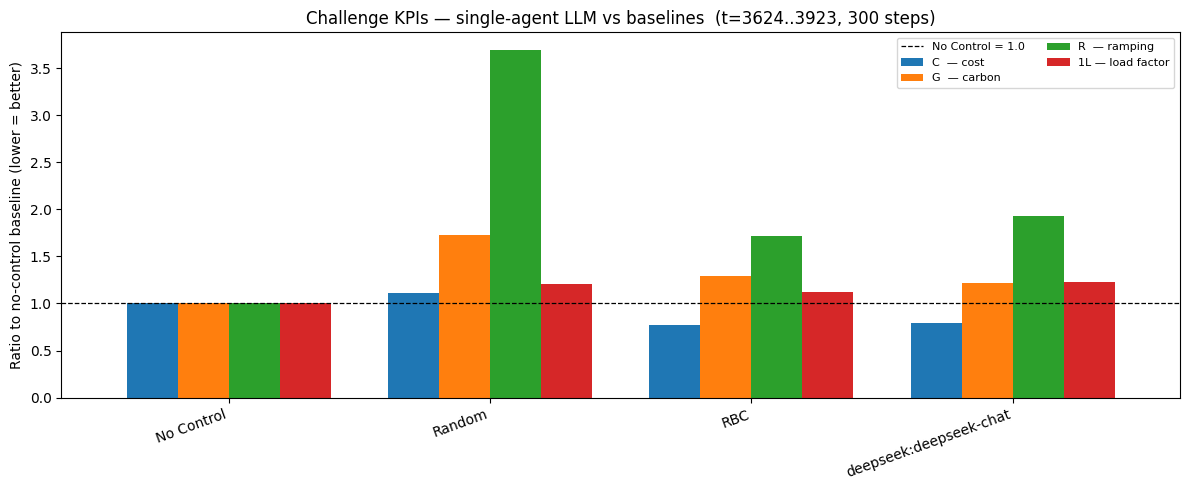

In [16]:
# Bar plot — Challenge KPIs (C, G, R, 1-L) per agent
kpi_cols = ["C  — cost", "G  — carbon", "R  — ramping", "1L — load factor"]
ax = challenge_df[kpi_cols].plot(kind="bar", figsize=(12, 5), width=0.78)
ax.axhline(1.0, color="k", ls="--", lw=0.9, label="No Control = 1.0")
ax.set_ylabel("Ratio to no-control baseline (lower = better)")
ax.set_title(
    f"Challenge KPIs — single-agent LLM vs baselines  "
    f"(t={WEEK_START}..{WEEK_START+WEEK_LEN-1}, {WEEK_LEN} steps)"
)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## § 14 — Per-Building Breakdown


In [17]:
def per_building_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Per-building action/SoC/reward summary for a single-agent rollout."""
    rows = []
    for b in range(N_BLDGS):
        rows.append({
            "run":           label,
            "building":      f"B{b}",
            "total_reward":  float(df[f"r{b}"].sum()),
            "mean_soc_pct":  float(df[f"soc{b}"].mean() * 100),
            "peak_net_kW":   float(df[f"net{b}"].max()),
            "total_net_kWh": float(df[f"net{b}"].sum()),
            "mean_action":   float(df[f"a{b}"].mean()),
            "std_action":    float(df[f"a{b}"].std()),
        })
    return pd.DataFrame(rows)


if llm_runs:
    per_b = pd.concat([
        per_building_summary(run["df"], name)
        for name, run in llm_runs.items()
    ], ignore_index=True)
    print(f"Per-building breakdown (buildings {BUILDINGS}):")
    display(per_b.set_index(["run", "building"]).round(4))
else:
    print("No LLM runs in llm_runs yet — run provider cells above.")


Per-building breakdown (buildings [0, 1, 2]):


total_reward  mean_soc_pct  peak_net_kW  total_net_kWh  \
run      building                                                           
deepseek B0           -563.6622       71.4787       6.8797       272.5299   
         B1           -597.2648       70.1997       7.2061       335.6718   
         B2           -311.7180       69.5813       4.9275       106.8728   

                   mean_action  std_action  
run      building                           
deepseek B0             0.0087      0.2074  
         B1             0.0027      0.2317  
         B2             0.0114      0.2086

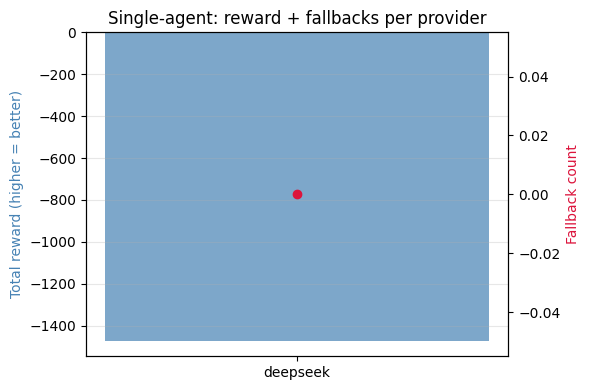

In [18]:
if llm_runs:
    fig, ax = plt.subplots(figsize=(6, 4))
    providers = list(llm_runs.keys())
    rewards   = [llm_runs[n]["df"]["reward_sum"].sum() for n in providers]
    fallbacks = [sum(1 for r in llm_runs[n]["raw_log"] if r["fallback"]) for n in providers]
    x = range(len(providers))
    ax2 = ax.twinx()
    ax.bar(x, rewards, alpha=0.7, color="steelblue", label="Total reward")
    ax2.plot(x, fallbacks, "o-", color="crimson", label="Fallbacks")
    ax.set_xticks(list(x)); ax.set_xticklabels(providers)
    ax.set_ylabel("Total reward (higher = better)", color="steelblue")
    ax2.set_ylabel("Fallback count", color="crimson")
    ax.set_title("Single-agent: reward + fallbacks per provider")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()


## § 15 — Diagnostics

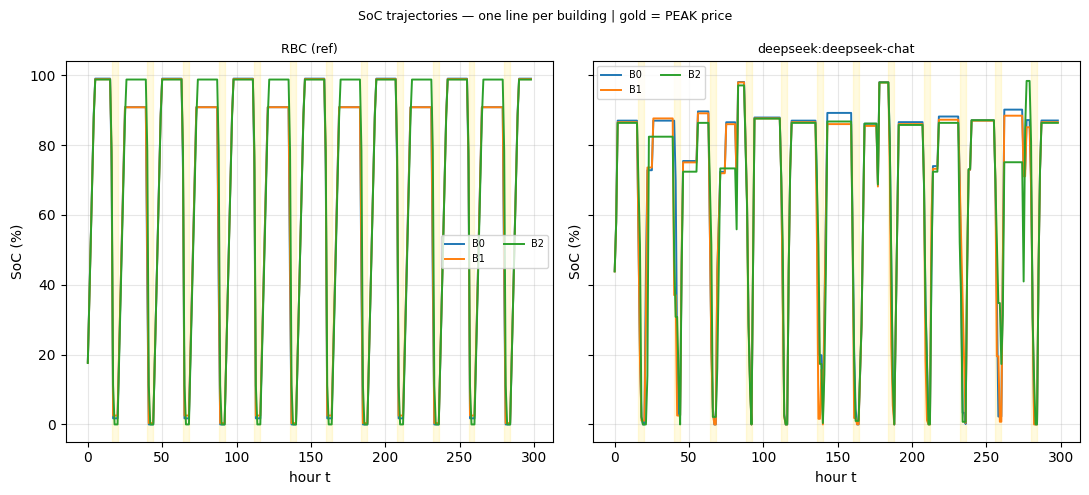

In [19]:
# 15.1  SoC trajectories — one line per building, PEAK price shaded
if not llm_runs:
    print("No LLM runs yet.")
else:
    panels = [(df_rbc, "RBC (ref)")] + [(run["df"], run["label"]) for run in llm_runs.values()]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 5), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    bldg_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    for ax, (df_, label) in zip(axes, panels):
        for b in range(N_BLDGS):
            ax.plot(df_["t"], df_[f"soc{b}"] * 100,
                    label=f"B{b}", lw=1.4, color=bldg_colors[b % len(bldg_colors)])

        peak_mask = (df_["price"] >= PRICE_PEAK_THRESHOLD).values
        in_peak, span_s = False, 0
        for i_m, is_peak in enumerate(peak_mask):
            if is_peak and not in_peak:
                span_s = i_m; in_peak = True
            elif not is_peak and in_peak:
                ax.axvspan(span_s, i_m - 1, color="gold", alpha=0.12); in_peak = False
        if in_peak:
            ax.axvspan(span_s, len(peak_mask) - 1, color="gold", alpha=0.12)

        ax.set_xlabel("hour t"); ax.set_ylabel("SoC (%)")
        ax.set_title(label, fontsize=9)
        ax.legend(ncol=2, fontsize=7); ax.grid(alpha=0.3)

    plt.suptitle("SoC trajectories — one line per building | gold = PEAK price", fontsize=9)
    plt.tight_layout()
    plt.show()


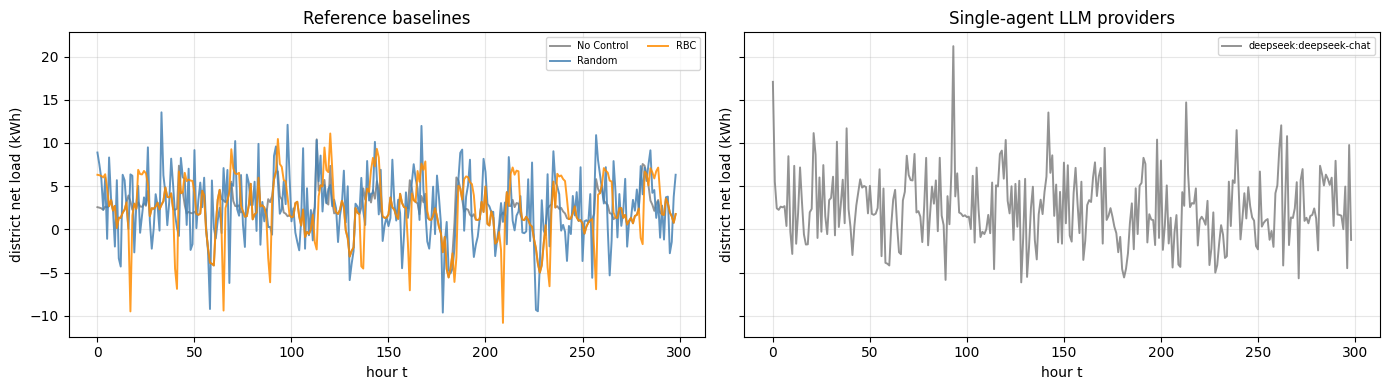

In [22]:
# 15.2  District net load comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

def _plot_net(ax, dfs_labels, title):
    colors = ["gray", "steelblue", "darkorange", "crimson", "forestgreen", "purple"]
    for (df_, lbl), color in zip(dfs_labels, colors):
        net = df_[[f"net{i}" for i in range(N_BLDGS)]].sum(axis=1)
        ax.plot(df_["t"], net, label=lbl, lw=1.4, color=color, alpha=0.85)
    ax.set_xlabel("hour t"); ax.set_ylabel("district net load (kWh)")
    ax.set_title(title); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

ref_panels = [(df_noop, "No Control"), (df_random, "Random"), (df_rbc, "RBC")]
_plot_net(axes[0], ref_panels, "Reference baselines")

llm_panels = [(run["df"], run["label"]) for run in llm_runs.values()]
if llm_panels:
    _plot_net(axes[1], llm_panels, "Single-agent LLM providers")
else:
    axes[1].text(0.5, 0.5, "No LLM runs yet", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


In [23]:
# 15.3  Behavioural summary per provider (rule violations, action stats)
def analyze_run(run: dict) -> dict:
    df       = run["df"]
    raw_log  = run["raw_log"]
    a_cols   = [f"a{i}"   for i in range(N_BLDGS)]
    soc_cols = [f"soc{i}" for i in range(N_BLDGS)]
    A        = df[a_cols].values
    fb       = float(np.mean([r["fallback"] for r in raw_log])) if raw_log else 0.0
    SOC_post = df[soc_cols].values
    SOC_pre  = np.vstack([np.zeros(N_BLDGS), SOC_post[:-1]])
    return {
        "provider":           run["label"],
        "fallback_pct":       round(fb * 100, 1),
        "charge_at_full":     int(((A > 0) & (SOC_pre >= 0.9)).sum()),
        "discharge_at_empty": int(((A < 0) & (SOC_pre <= 0.1)).sum()),
        "mean_action":        round(float(A.mean()), 3),
        "std_action":         round(float(A.std()), 3),
    }


if llm_runs:
    beh_df = pd.DataFrame([analyze_run(run) for run in llm_runs.values()])
    print("Behavioural summary:")
    display(beh_df.set_index("provider").round(3))
    print(
        "\nfallback_pct = timeout + parse failures (target: 0).\n"
        "charge_at_full / discharge_at_empty = prompt-rule violations."
    )


Behavioural summary:


,fallback_pct,charge_at_full,discharge_at_empty,mean_action,std_action
provider,,,,,
deepseek:deepseek-chat,0.0,0,0,0.02,0.27



fallback_pct = timeout + parse failures (target: 0).
charge_at_full / discharge_at_empty = prompt-rule violations.


In [24]:
# 15.4  Sample raw responses — 1 timestep per provider
N_SHOW = 1

if not llm_runs:
    print("No LLM runs yet.")
else:
    rng_diag = np.random.default_rng(SEED)
    ref_log  = next(iter(llm_runs.values()))["raw_log"]
    picked   = sorted(rng_diag.choice(len(ref_log), size=min(N_SHOW, len(ref_log)), replace=False).tolist())

    for idx in picked:
        t_val = ref_log[idx]["t"]
        print("=" * 72)
        print(f"t={t_val}")
        for name, run in llm_runs.items():
            entry = run["raw_log"][idx]
            print(f"\n-- {run['label']} --")
            print(f"  State:\n{entry['state_text']}")
            print(f"  Response (fallback={entry['fallback']}):\n{entry['raw']}")
        print()


t=26

-- deepseek:deepseek-chat --
  State:
Month 12, Sat 01:00  |  price=0.210 (LOW)  |  carbon=0.186 (MID)
Buildings:
  B0: SoC= 55.4%  load=2.63 kWh  last_net=+0.55 kWh  solar=NONE
  B1: SoC= 57.2%  load=1.56 kWh  last_net=-0.04 kWh  solar=NONE
  B2: SoC= 64.6%  load=0.25 kWh  last_net=-0.78 kWh  solar=NONE
  Response (fallback=False):
<thought>Late night, low price, mid carbon. Solar none. Last net near zero. Charge gently to avoid ramping and peak. Small actions safe.</thought>
<action building=0>CHARGE_20</action>
<action building=1>CHARGE_20</action>
<action building=2>CHARGE_20</action>



## § 16 — Save Artifacts

In [ ]:
stamp = time.strftime("%Y%m%d_%H%M%S")

# ── Rollout CSVs ──────────────────────────────────────────────────────────
all_dfs = [df_noop, df_random, df_rbc] + [run["df"] for run in llm_runs.values()]
df_all  = pd.concat(all_dfs, ignore_index=True)
csv_path = ARTIFACTS / f"02_rollouts_{stamp}.csv"
df_all.to_csv(csv_path, index=False)
print(f"Rollout data    : {csv_path}")

# ── KPI tables (Challenge + ZNE via src.eval) ─────────────────────────────
kpi_path = ARTIFACTS / f"02_challenge_{stamp}.csv"
challenge_df.to_csv(kpi_path)
print(f"Challenge table : {kpi_path}")
zne_path = ARTIFACTS / f"02_zne_{stamp}.csv"
zne_df.to_csv(zne_path)
print(f"ZNE table       : {zne_path}")

# ── Per-building summary ──────────────────────────────────────────────────
if llm_runs:
    per_b_path = ARTIFACTS / f"02_per_building_{stamp}.csv"
    per_b.to_csv(per_b_path, index=False)
    print(f"Per-building    : {per_b_path}")

# ── Raw LLM logs (JSON) ───────────────────────────────────────────────────
for name, run in llm_runs.items():
    log_path = ARTIFACTS / f"02_raw_{name}_{stamp}.json"
    with open(log_path, "w") as f:
        json.dump(run["raw_log"], f, indent=2)
    print(f"Raw log {name:10s}: {log_path}")
